In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
np.set_printoptions(suppress=True)

import json

with open('../config.json', 'r') as f:
    config = json.load(f)

ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = [el for el in ELEMENTS_TO_KEEP if el != 'Fe']
NORMALISATION_TO_FE = config["normalisation_to_Fe"]

PREDICTION_PATH_DICT = config["prediction_path"]
PREPROCESSED_DATA_PATH_DICT = config["preprocessed_data_path"]
FIGURES_PATH = config["figures_path"]['all']

DATASETS = ['Konstytucja', 'corroded', 'Merkuriusz', 'Kopernik']

CMAP = plt.get_cmap('tab20')

In [2]:
df, y_true = join_datasets_into_one(
                            DATASETS, 
                            PREDICTION_PATH_DICT,
                            PREPROCESSED_DATA_PATH_DICT,
                            ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP
                            )

X = np.array(df.values)

In [3]:
from sklearn.decomposition import PCA

n_components = 3
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [4]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.components_

array([[-0.00292304,  0.12571896, -0.17408311,  0.38863262,  0.43133281,
         0.40846067,  0.59896285,  0.04379607,  0.19918214,  0.13299589,
         0.06671323,  0.16574427],
       [-0.11621012, -0.46253929, -0.29128221, -0.01097115, -0.21107453,
         0.46715436,  0.09691352,  0.16791403, -0.15062535, -0.23568533,
        -0.38148093, -0.40429031],
       [ 0.12906633, -0.05331892,  0.2814238 , -0.04472358,  0.01059179,
         0.1652421 , -0.20831647,  0.83600454,  0.33378978,  0.07361787,
         0.10661131,  0.03717202]])

In [5]:
pca.components_[0,:] #PC1

array([-0.00292304,  0.12571896, -0.17408311,  0.38863262,  0.43133281,
        0.40846067,  0.59896285,  0.04379607,  0.19918214,  0.13299589,
        0.06671323,  0.16574427])

In [6]:
pca.components_[1,:] #PC2

array([-0.11621012, -0.46253929, -0.29128221, -0.01097115, -0.21107453,
        0.46715436,  0.09691352,  0.16791403, -0.15062535, -0.23568533,
       -0.38148093, -0.40429031])

In [7]:
pca.components_[2,:] #PC3

array([ 0.12906633, -0.05331892,  0.2814238 , -0.04472358,  0.01059179,
        0.1652421 , -0.20831647,  0.83600454,  0.33378978,  0.07361787,
        0.10661131,  0.03717202])

In [8]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.explained_variance_ratio_

array([0.51347053, 0.14999472, 0.10589529])

In [9]:
# elements corresponding to consecutive dimensions
print(ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP)

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Fe', 'Mg', 'Na', 'K']


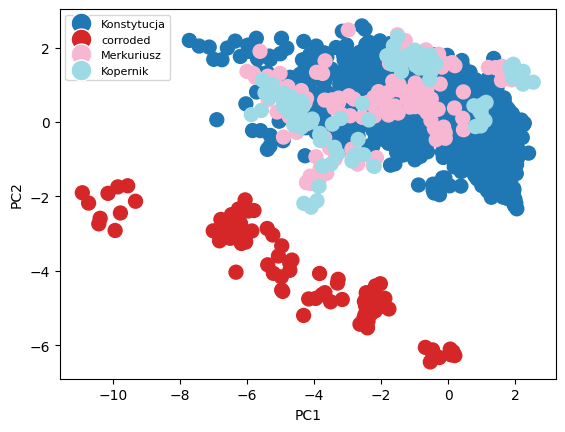

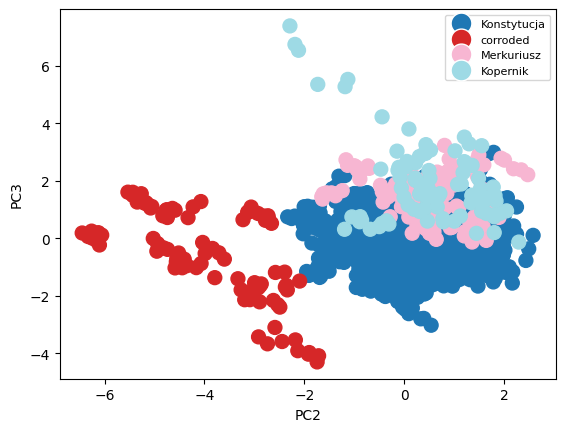

In [10]:
visualise_pca(X_pca, y_true, dimensions=[0,1], whether_sort=False, figures_path=None)

visualise_pca(X_pca, y_true, dimensions=[1, 2], whether_sort=False, figures_path=None)

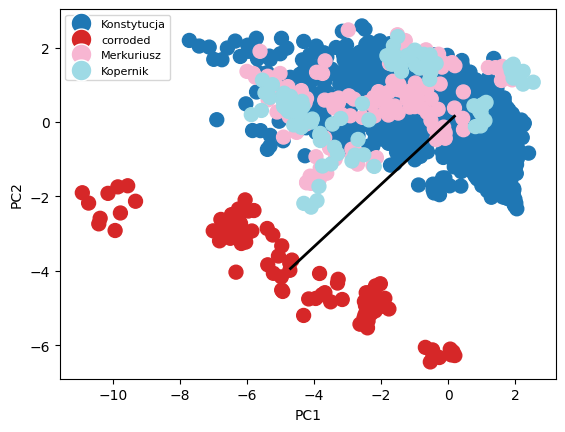

In [11]:
# let's choose some interesting dimensions and project data onto it
dimensions=[0,1]

pc1 = X_pca[:, dimensions[0]]
pc2 = X_pca[:, dimensions[1]]
X_2d = np.column_stack((pc1, pc2))

# let's find means of class 'not corroded' and 'corroded' (on PC plane, 2D)
class0 = X_2d[y_true != 'corroded']
class1 = X_2d[y_true == 'corroded']

mu0 = class0.mean(axis=0)
mu1 = class1.mean(axis=0)

# let's draw a vector from mu0 to m1 just using simple formula t*mu0 + (1-t)*mu1 (all points in between)
t = np.linspace(0, 1, 100)
x_interval = mu0[0]*t + (1-t) * mu1[0]
y_interval = mu0[1]*t + (1-t) * mu1[1]

plt.plot(x_interval, y_interval, 'black', linewidth=2)
visualise_pca(X_pca, y_true, dimensions=dimensions, whether_sort=False, figures_path=None);

In [12]:
#vector from not corroded to corroded (on PC plane, 2D)
w = mu1 - mu0
w = w.reshape(1,-1) #to get horizontal vector

# the entries of vector w are the coefficients in the PC basis
# so the actual vector w in standard basis is different
# it is a sum of two vectors: first PC rescaled by w[0] plus second PC rescaled by w[1]
# so to get the equivalent of w in high dimensional space we need matrix multiplication
vector_in_9d = w @ pca.components_[dimensions, :]
print(vector_in_9d)
print('-----------------')
print(vector_in_9d/np.sum(np.abs(vector_in_9d/2)))
# now the consecutive entries of this vector correspond to consecutive elements from ELEMENTS_TO_KEEP_NO_FE list
# those elements that correspond to positive entries pull the point towards corroded group
# (are consistent with the direction of vector mu1-mu0, i.e. from mu0 to mu1
# those that correspond to negative entries pull toward not corroded group

[[ 0.48971258  1.2781774   2.04208243 -1.85359969 -1.24353811 -3.90654516
  -3.32244322 -0.90090741 -0.35678059  0.31453506  1.23480038  0.8443468 ]]
-----------------
[[ 0.05506265  0.14371661  0.22960911 -0.20841635 -0.13982182 -0.43924689
  -0.37357122 -0.10129686 -0.04011595  0.03536592  0.13883936  0.09493726]]


In [13]:
ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Fe', 'Mg', 'Na', 'K']

In [14]:
# sanity check: project it back to 2D PC plane
# we should get exactly mu1-mu0
V = pca.components_[dimensions]
res = V @ vector_in_9d.T
print(res)
print('-------------')
print(mu1-mu0)
print('-------------')
# ok

[[-4.88503608]
 [-4.09115316]]
-------------
[-4.88503608 -4.09115316]
-------------


In [15]:
# ATTENTION
# pca.transform will not work
pca.transform(vector_in_9d)[:, dimensions]
# it is not equal to mu1-mu0, because transform also does shifting (centering)

array([[-26.08740946,   9.75380303]])